In [95]:
import sys, os

import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

In [2]:
# Local project imports
sys.path.append(os.path.join(os.getcwd(), 'Documents', 'time_of_emergene_drafts'))
sys.path.append(os.path.join(os.getcwd(), 'Documents', 'time_of_emergene_drafts', 'src'))


import constants
import climate_utils


In [3]:
from dask.distributed import Client, wait
client = Client(threads_per_worker=1, memory_limit=None, n_workers=4)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45319 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/45319/status,
Dashboard: /proxy/45319/status,Workers: 4
Total threads: 4,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41613,Workers: 0
Dashboard: /proxy/45319/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43177,Total threads: 1
Dashboard: /proxy/38397/status,Memory: 0 B
Nanny: tcp://127.0.0.1:35589,


In [4]:

PI_CHUNKS = {'time':-1, 'lat':'auto', 'lon':'auto'}
version = '04'
PICONTROL_PATH = os.path.join(constants.TOE_SAVE_DIR, f'access_ssp585_tas_(1880_1909)_{version}/piControl_tas.zarr')
pi_ds = xr.open_dataset(PICONTROL_PATH, engine='zarr', use_cftime=True).chunk(PI_CHUNKS).persist()['tas']
wait(pi_ds);
pi_ds

/jobfs/162823156.gadi-pbs/ipykernel_2514361/1378093327.py:4: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  pi_ds = xr.open_dataset(PICONTROL_PATH, engine='zarr', use_cftime=True).chunk(PI_CHUNKS).persist()['tas']


<xarray.DataArray 'tas' (time: 1000, lat: 72, lon: 144)> Size: 83MB
dask.array<xarray-tas, shape=(1000, 72, 144), dtype=float64, chunksize=(1000, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8kB 0101-12-31 00:00:00 ... 1100-12-31 00:00:00
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
    height   float64 8B ...

In [5]:
# Global mean (ensemble members retained)
smean_ds = climate_utils.weighted_lat_lon_mean(pi_ds).compute()

In [6]:
smean_ds

<xarray.DataArray 'tas' (time: 1000)> Size: 8kB
array([287.44725252, 287.58786057, 287.65730466, 287.53174974,
       287.51939502, 287.62865631, 287.59312595, 287.62049723,
       287.62235376, 287.64007044, 287.7224679 , 287.75080406,
       287.70094386, 287.64026091, 287.60355963, 287.6543829 ,
       287.56867963, 287.56529814, 287.42767538, 287.62356791,
       287.64452155, 287.53422408, 287.61138114, 287.68005902,
       287.58375368, 287.69397342, 287.6952259 , 287.5444969 ,
       287.73434851, 287.79279347, 287.74554272, 287.66102272,
       287.6200591 , 287.74204487, 287.77362332, 287.73575744,
       287.57773011, 287.63229774, 287.72003952, 287.76513204,
       287.56496854, 287.6176224 , 287.59093084, 287.63298667,
       287.64835973, 287.78634981, 287.65950273, 287.62927719,
       287.70140831, 287.57387474, 287.71493852, 287.75207219,
       287.45670627, 287.56919872, 287.69308735, 287.77368529,
       287.67859812, 287.75128118, 287.7610113 , 287.71818184,
       287.71654713, 287.52769055, 287.51878546, 287.51620683,
       287.59206583, 287.50088522, 287.53853847, 287.49643049,
       287.4955409 , 287.51480237, 287.67011047, 287.5802181 ,
       287.58708028, 287.42900469, 287.43763843, 287.54188504,
       287.34924792, 287.41828266, 287.60306022, 287.64660369,
...
       287.62977992, 287.80776744, 287.77812919, 287.81197707,
       287.70253588, 287.67029391, 287.70773037, 287.73985711,
       287.73793199, 287.56524628, 287.70740035, 287.72351633,
       287.77144936, 287.83882581, 287.72989198, 287.70156785,
       287.7637763 , 287.75452213, 287.57423338, 287.68408009,
       287.85416471, 287.71169016, 287.7457245 , 287.8589627 ,
       287.8972224 , 287.90499215, 287.84858099, 287.76600425,
       287.66337266, 287.70582051, 287.700922  , 287.52742647,
       287.60396763, 287.61164112, 287.7775344 , 287.73785711,
       287.65525909, 287.64221266, 287.54047292, 287.53007555,
       287.58858481, 287.56810229, 287.61036118, 287.47353688,
       287.5256053 , 287.3990269 , 287.56085977, 287.6283967 ,
       287.51439872, 287.65254739, 287.67171444, 287.60643241,
       287.67912559, 287.68147404, 287.75040467, 287.70842779,
       287.71672068, 287.57739464, 287.61154089, 287.6836655 ,
       287.79345202, 287.72708823, 287.6351543 , 287.62631129,
       287.67399128, 287.64659005, 287.57831082, 287.71126801,
       287.68761565, 287.57044545, 287.55886299, 287.47607974,
       287.61888743, 287.59697853, 287.66599269, 287.7045351 ,
       287.62714163, 287.5500674 , 287.61562659, 287.7135912 ])
Coordinates:
  * time     (time) object 8kB 0101-12-31 00:00:00 ... 1100-12-31 00:00:00
    height   float64 8B 2.0

In [11]:
# trend = smean_ds.rolling(time=20, center=True).mean()

In [77]:
smean_dtrend_ds = smean_ds# - trend

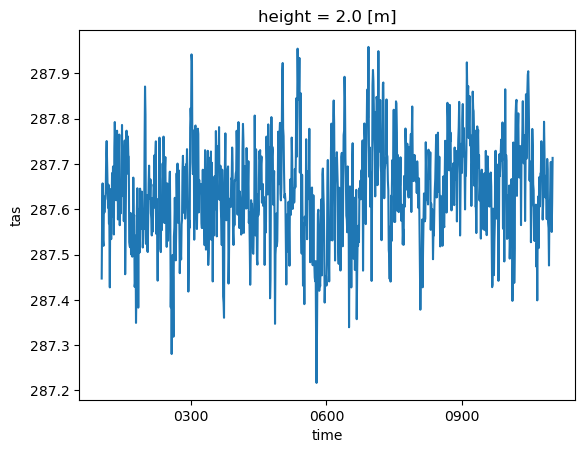

In [78]:
smean_dtrend_ds.plot()

In [79]:
from dask import compute, delayed
import pandas as pd

In [80]:
@delayed
def calc_std_vals(da, window):
    return da.rolling(time=window, center=True, min_periods=window).std().values

In [89]:
std_dict = {}
for window in np.arange(10, 300, 1):
    std_dict[window]  = calc_std_vals(smean_dtrend_ds, window)

keys, tasks = zip(*std_dict.items())
results = compute(*tasks)

result_dict = dict(zip(keys, results))

In [90]:
result_df = pd.DataFrame(result_dict)
result_df.head()

,10,11,12,13,14,15,16,17,18,19,...,290,291,292,293,294,295,296,297,298,299
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
stats_df = result_df.quantile([0.1, 0.25, 0.50, 0.75, 0.9], axis=0)


/jobfs/162823156.gadi-pbs/ipykernel_2514361/415819228.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


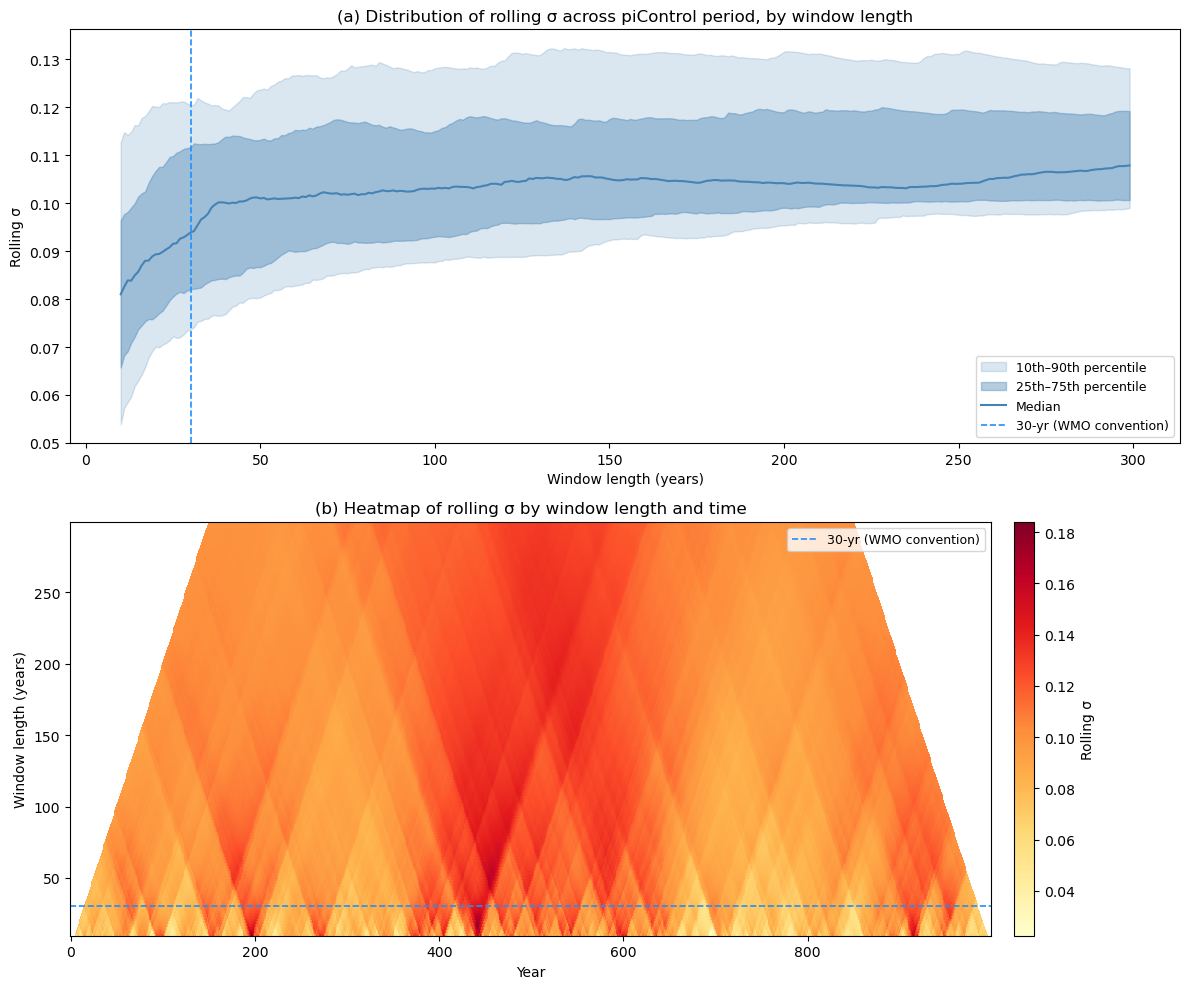

In [96]:

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Panel 1: spread of σ across time, by window length ---
ax1 = axes[0]

ax1.fill_between(stats_df.columns, stats_df.loc[0.1], stats_df.loc[0.9], 
                  alpha=0.2, color='steelblue', label='10th–90th percentile')
ax1.fill_between(stats_df.columns, stats_df.loc[0.25], stats_df.loc[0.75], 
                  alpha=0.4, color='steelblue', label='25th–75th percentile')
ax1.plot(stats_df.columns, stats_df.loc[0.50], 
          color='steelblue', lw=1.5, label='Median')

ax1.axvline(30, color='dodgerblue', lw=1.2, ls='--', label='30-yr (WMO convention)')
ax1.set_xlabel('Window length (years)')
ax1.set_ylabel('Rolling σ')
ax1.set_title('(a) Distribution of rolling σ across piControl period, by window length')
ax1.legend(fontsize=9)

# --- Panel 2: Heatmap (unchanged) ---
ax2 = axes[1]

heatmap_data = result_df.T  # rows = window length, columns = time

im = ax2.pcolormesh(result_df.index, result_df.columns.astype(int), heatmap_data.values,
                     cmap='YlOrRd', shading='auto')

cbar = fig.colorbar(im, ax=ax2, pad=0.02)
cbar.set_label('Rolling σ', fontsize=10)

ax2.set_xlabel('Year')
ax2.set_ylabel('Window length (years)')
ax2.set_title('(b) Heatmap of rolling σ by window length and time')
ax2.axhline(30, color='dodgerblue', lw=1.2, ls='--', label='30-yr (WMO convention)')
ax2.legend(fontsize=9)

# plt.tight_layout()
# plt.savefig('rolling_sigma_panels.png', dpi=150, bbox_inches='tight')
# plt.show()

In [92]:
stats_df = result_df.quantile([0.1, 0.25, 0.50, 0.75, 0.9], axis=0)
stats_df.head()

,10,11,12,13,14,15,16,17,18,19,...,290,291,292,293,294,295,296,297,298,299
0.10,0.053854,0.057282,0.058488,0.059639,0.061834,0.062973,0.064232,0.065795,0.067825,0.069086,...,0.098529,0.098575,0.098586,0.098674,0.098620,0.098747,0.098758,0.098743,0.098870,0.099005
0.25,0.065743,0.068285,0.069127,0.070881,0.072139,0.073683,0.074505,0.075359,0.075848,0.075785,...,0.100535,0.100607,0.100604,0.100649,0.100647,0.100757,0.100743,0.100660,0.100672,0.100643
0.50,0.081005,0.082558,0.083890,0.083838,0.084929,0.085693,0.087029,0.087994,0.088022,0.088879,...,0.107100,0.107108,0.107238,0.107268,0.107342,0.107578,0.107755,0.107740,0.107786,0.107890
0.75,0.096454,0.097749,0.098182,0.099084,0.099955,0.101375,0.102054,0.102461,0.104280,0.105636,...,0.118449,0.118354,0.118377,0.118659,0.118836,0.119139,0.119261,0.119256,0.119276,0.119208
0.90,0.112806,0.114809,0.114239,0.114897,0.116277,0.116263,0.117785,0.118173,0.119163,0.120278,...,0.128781,0.128652,0.128780,0.128746,0.128639,0.128483,0.128420,0.128309,0.128176,0.128140


<Axes: >

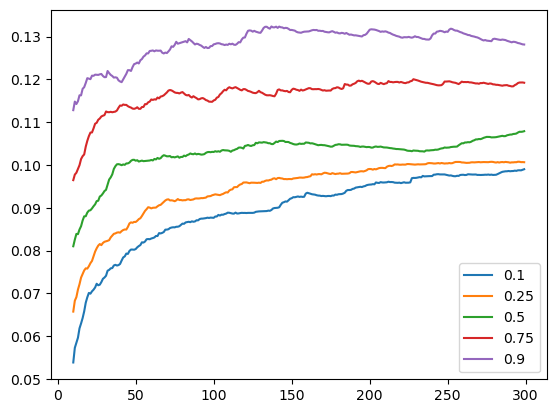

In [93]:
stats_df.T.plot()

# Longer Picontrol

In [55]:
path = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/tas/gn/latest/'

In [57]:
files = os.listdir(path)
files

['tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_010101-060012.nc',
 'tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060101-100012.nc',
 'tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_100101-110012.nc']

In [62]:
file_da = []

for file in files:
    print(file)
    da = xr.open_dataset(os.path.join(path, file), engine='h5netcdf', use_cftime=True)
    file_da.append(da)

tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_010101-060012.nc
tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060101-100012.nc


/jobfs/162823156.gadi-pbs/ipykernel_2514361/3513706642.py:5: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  da = xr.open_dataset(os.path.join(path, file), engine='h5netcdf', use_cftime=True)
/jobfs/162823156.gadi-pbs/ipykernel_2514361/3513706642.py:5: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  da = xr.open_dataset(os.path.join(path, file), engine='h5netcdf', use_cftime=True)


tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_100101-110012.nc


/jobfs/162823156.gadi-pbs/ipykernel_2514361/3513706642.py:5: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  da = xr.open_dataset(os.path.join(path, file), engine='h5netcdf', use_cftime=True)


In [63]:
all_da = xr.concat(file_`da, dim='time')

/jobfs/162823156.gadi-pbs/ipykernel_2514361/2276065344.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  all_da = xr.concat(file_da, dim='time')


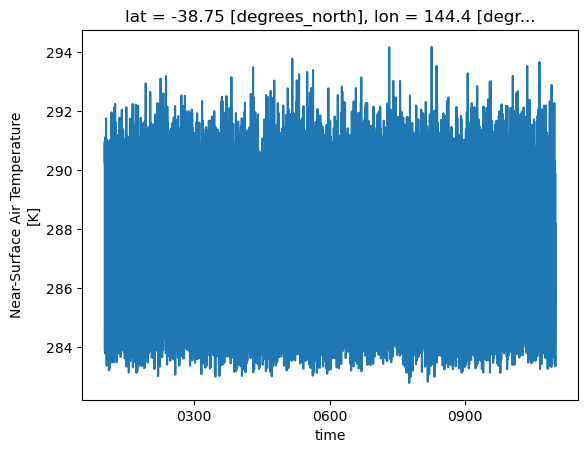

In [66]:
all_da.tas.sel(lat=-39, lon=145, method='nearest').plot()

In [50]:
file = '/g/

data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_010101-060012.nc'

In [52]:
da = xr.open_dataset(file, engine='h5netcdf')

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 101-01-01. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0101-01-01). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/jobfs/162823156.gadi-pbs/ipykernel_2514361/2016050542.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  da = xr.open_dataset(file, engine='h5netcdf')


In [53]:
da

<xarray.Dataset> Size: 668MB
Dimensions:    (time: 6000, bnds: 2, lat: 145, lon: 192)
Coordinates:
  * time       (time) object 48kB 0101-01-16 12:00:00 ... 0600-12-16 12:00:00
  * lat        (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon        (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 96kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 668MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36524.0
    creation_date:          2019-11-12T05:32:13Z
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    version:                v20191112
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/6e9eac06-87dd-40b0-8ceb-c95a76538698
    license:                CMIP6 model data produced by CSIRO is licensed un...

In [ ]:
path = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/tas/gn/latest/*.nc'

In [54]:
td = xr.open_mfdataset(path, engine='h5netcdf', use_cftime=True)

IsADirectoryError: [Errno 21] Unable to synchronously open file (file read failed: time = Wed Mar 11 16:10:42 2026
, filename = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/tas/gn/v20210316', file descriptor = 141, errno = 21, error message = 'Is a directory', buf = 0x7ffdb184f260, total read size = 8, bytes this sub-read = 8, bytes actually read = 18446744073709551615, offset = 0)

In [7]:
path = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/tas/gn/v20210316/'
os.listdir(path)

['tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_010101-060012.nc',
 'tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060101-100012.nc',
 'tas_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_100101-110012.nc']

In [8]:
td = xr.open_mfdataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/tas/gn/v20210316/*.nc')

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'argo' loading failed:
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/netCDF4/../../../././libmpi_mpifh.so.40: undefined symbol: ompi_instance_count
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
INFO:httpx:HTTP Request: GET https://raw.githubusercontent.com/IrishMarineInstitute/awesome-erddap/master/erddaps.json "HTTP/1.1 200 OK"
INFO:matplotlib.font_manager:generated new fontManager
/opt/conda/analysis3-26.03/bin/gmt: symbol lookup error: /opt/conda/analysis3-26.03/bin/../lib/./././libmpi_mpifh.so.40: undefined symbol: ompi_instance_count
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.so'.
/g/data/xp65/public/apps/med_conda/

ImportError: /g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/netCDF4/../../../././libmpi_mpifh.so.40: undefined symbol: ompi_instance_count

In [ ]:
td